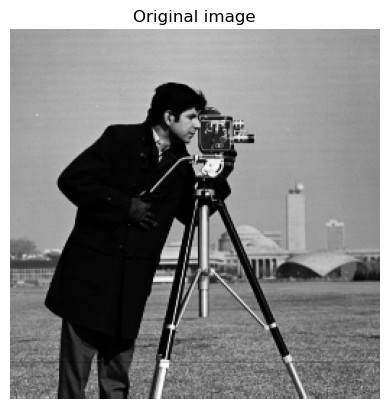

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
I=cv2.imread('cameraman.png',0)
I=cv2.resize(I,(256,256))
x=I.flatten()
plt.imshow(I,cmap='gray')
plt.axis('off')
plt.title('Original image')
plt.show()

Total number of bits=524288


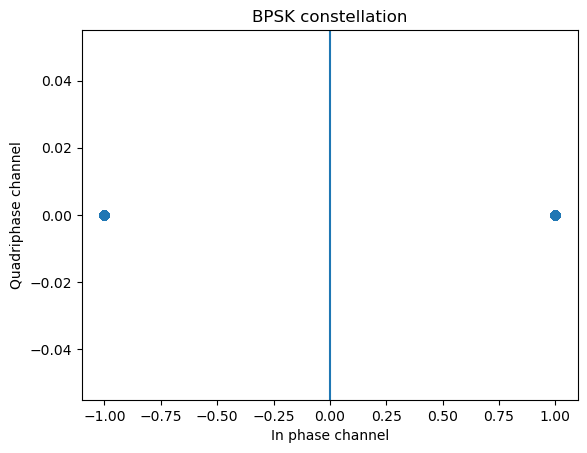

In [2]:
bitstream=[]
for pixel in x:
    bits=format(int(pixel),'08b')
    bitstream.extend([int(b) for b in bits])
bitstream=np.array(bitstream)
print(f'Total number of bits={len(bitstream)}')
a=np.where(bitstream==0,1,-1)
plt.scatter(a[:1000],np.zeros(1000))
plt.title('BPSK constellation')
plt.xlabel('In phase channel')
plt.ylabel('Quadriphase channel')
plt.axvline(0)
plt.show()

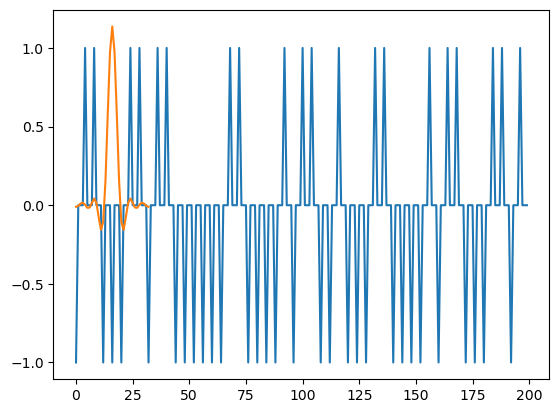

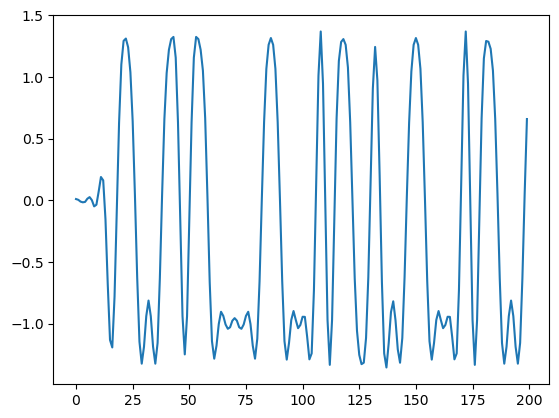

Ber value for SNR =0=0.065460205078125


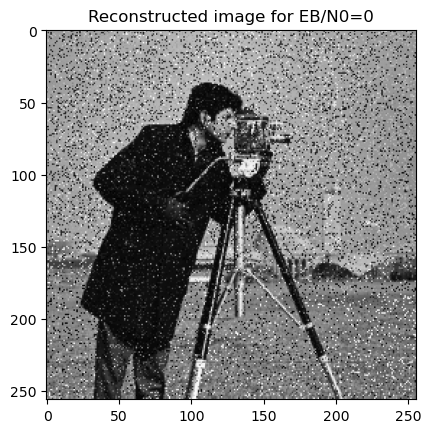

Ber value for SNR =2=0.037166595458984375


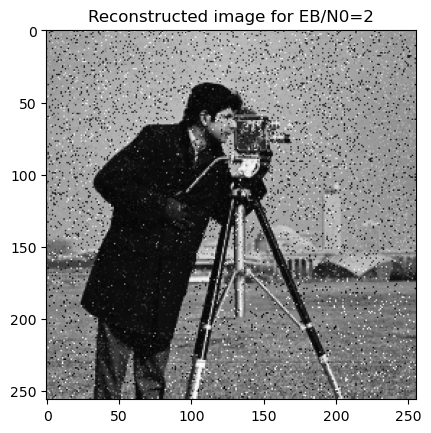

Ber value for SNR =4=0.018201828002929688


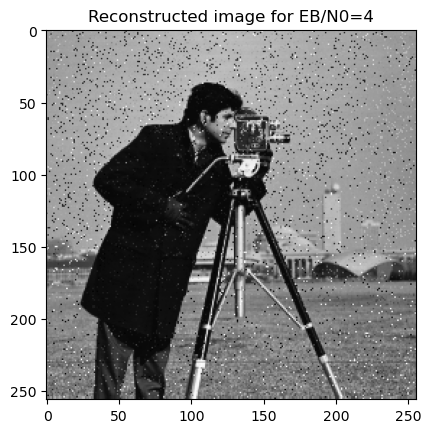

Ber value for SNR =6=0.00742340087890625


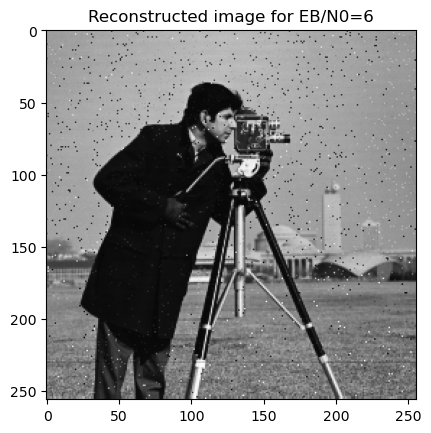

Ber value for SNR =8=0.0020694732666015625


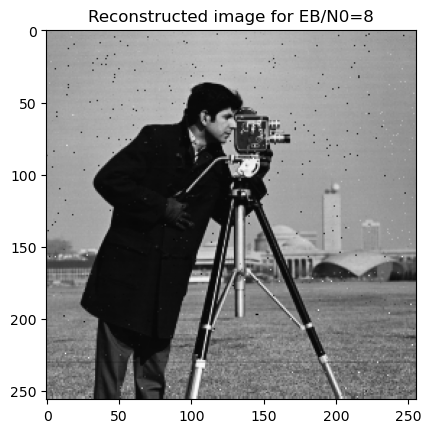

Ber value for SNR =10=0.000408172607421875


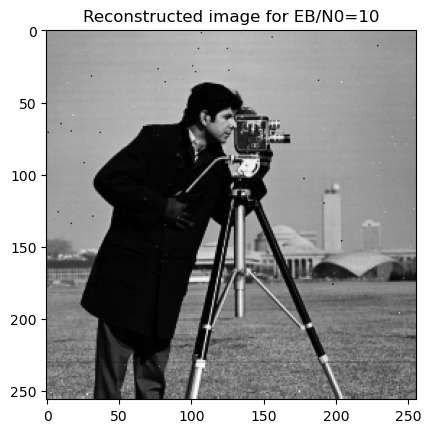

Ber value for SNR =12=2.6702880859375e-05


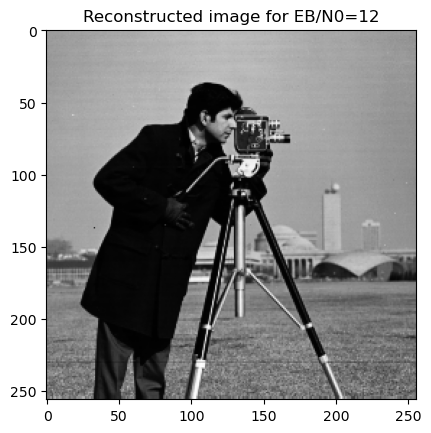

Ber value for SNR =14=0.0


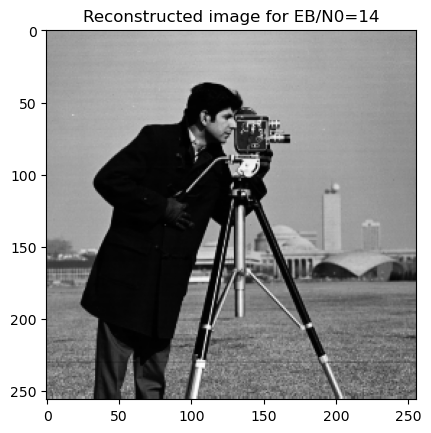

Ber value for SNR =16=0.0


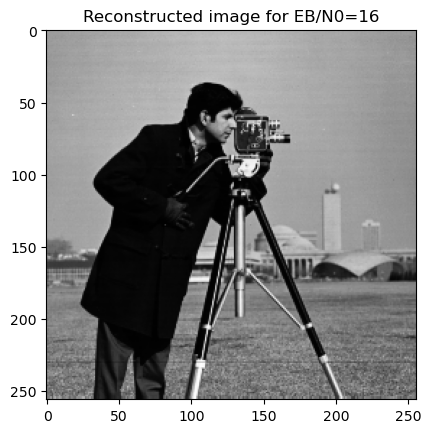

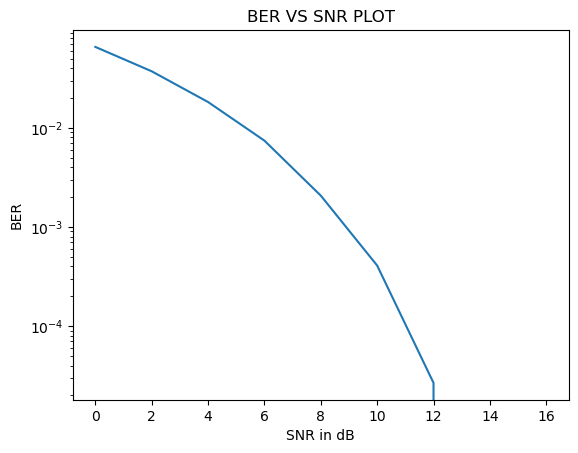

In [3]:
L=4
Nsym=8
Tsym=1
B=0.5
u=np.zeros(len(a)*L)
for i in range(len(a)):
    u[i*L]=a[i]
plt.plot(u[:200])
p=[]
T = np.arange(-Nsym/2, Nsym/2 + 1/L, 1/L)
for t in T:
    if t==0:
        p.append((1+B*(4/(np.pi)-1))/np.sqrt(Tsym))
    elif t==Tsym/(4*B) or t==-Tsym/(4*B):
        p.append(B*((1+2/np.pi)*np.sin(np.pi/(4*B))+(1-2/np.pi)*np.cos(np.pi/(4*B)))/np.sqrt(2*Tsym))
    else:
        p.append(4*B*(np.cos((1+B)*np.pi*t/Tsym)+(Tsym/(4*B*t))*np.sin((1-B)*np.pi*t/Tsym))/((1-(4*B*t/Tsym)**2)*np.pi*np.sqrt(Tsym)))
p=np.array(p)
plt.plot(np.arange(len(p)),p)
plt.show()
s=np.convolve(u,p)
plt.plot(s[:200])
plt.show()


SNR = [0,2,4,6,8,10,12,14,16]
Ps = (1/len(s))*np.sum(np.abs(s)**2)
BER_sim=[]

for i in SNR :
    SNR_lin = 10**(i/10)
    Pn= Ps/SNR_lin
    w=np.sqrt(Pn)* np.random.normal(0,1,len(s))
    r=s+w
    g=p
    y=np.convolve(r,g)
    arx=[]
    for j in range(len(p),len(y)+1,L):
      arx.append(y[j])
    arx=np.array(arx)
    brx=np.where(arx>=0,0,1)
    brx=brx[:len(bitstream)]
    bit_errors=np.sum(bitstream!=brx[:len(bitstream)])
    BER=bit_errors/len(bitstream)
    BER_sim.append(BER)
    print(f'Ber value for SNR ={i}={BER}')
    brx_reshaped=brx.reshape(-1,8)
    pixel_rx=[]
    for byte in brx_reshaped:
        value=0
        for bit in byte:
            value=(value<<1)|bit
        pixel_rx.append(value)
    pixel_rx=np.array(pixel_rx)
    img_rx=pixel_rx.reshape(256,256)
    plt.figure()
    plt.imshow(img_rx,cmap='gray')
    plt.title(f'Reconstructed image for EB/N0={i}')
    plt.show()
plt.title("BER VS SNR PLOT")
plt.xlabel("SNR in dB")
plt.ylabel("BER")
plt.semilogy(SNR,BER_sim)
plt.show()






